In [1]:
print('test to make sure venv is working')

test to make sure venv is working


# Python Imports From Venvironment

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Notebook Settings to Help With Development

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

plt.style.use('seaborn-v0_8')

# Create Folders For Data 

In [4]:
RAW_DATA_PATH = Path('../data/raw')
PROCESSED_DATA_PATH = Path('../data/processed')

In [5]:
# Check to see if the directories exist, if not create 
if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {RAW_DATA_PATH}")
else:
    print(f"Directory already exists: {RAW_DATA_PATH}")

if not PROCESSED_DATA_PATH.exists():
    PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {PROCESSED_DATA_PATH}")
else:
    print(f"Directory already exists: {PROCESSED_DATA_PATH}")

Directory already exists: ..\data\raw
Directory already exists: ..\data\processed


# Data Tickers and Time Range

In yFinance library data is stored with their ticker symbols.

In [17]:
TICKERS = [
    "AAPL",  # Apple Inc.
    "MSFT",  # Microsoft Corporation
    "GOOGL", # Alphabet Inc. (Google)
    "NVDA",  # NVIDIA Corporation
    "AMZN",  # Amazon.com, Inc.
    "JPM",   # JPMorgan Chase & Co.
    "XOM",   # Exxon Mobil Corporation
    "JNJ",   # Johnson & Johnson
    "PG",    # Procter & Gamble Co.
    "TSLA",  # Tesla, Inc.
    "SPY",   # S&P 500 ETF
    "QQQ",   # Nasdaq-100 ETF
    "AGG",   # iShares Core U.S. Aggregate Bond ETF
    "GLD",   # SPDR Gold Shares
]

In [18]:
START_DATE = "2018-01-01" # Doing small sample first
END_DATE = "2025-12-31"  # End date for data acquisition

# Download Data From Yahoo Finance

## NOTE: 
I don't know how big the data is going to be, so I will download a small sample first.

In [19]:
market_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="column",
)

[*********************100%***********************]  14 of 14 completed


# Investigate the Data

In [20]:
market_data.head()

Price       Adj Close                                                                                           \
Ticker           AAPL        AGG       AMZN         GLD      GOOGL         JNJ        JPM       MSFT      NVDA   
Date                                                                                                             
2018-01-02  40.267078  85.561790  59.450500  125.150002  53.188869  110.130806  85.901253  78.699890  4.922531   
2018-01-03  40.260063  85.569595  60.209999  124.820000  54.096317  111.182846  85.988792  79.066162  5.246500   
2018-01-04  40.447067  85.514763  60.479500  125.459999  54.306446  111.174911  87.220634  79.762085  5.274156   
2018-01-05  40.907578  85.459900  61.457001  125.330002  55.026569  112.092522  86.660721  80.750931  5.318850   
2018-01-08  40.755634  85.436424  62.343498  125.309998  55.220840  112.234863  86.788727  80.833359  5.481825   

Price                                                                    Close                                     \
Ticker             PG         QQQ         SPY       TSLA        XOM       AAPL         AGG       AMZN         GLD   
Date                                                                                                                
2018-01-02  72.280716  150.057220  235.954315  21.368668  58.185493  43.064999  109.169998  59.450500  125.150002   
2018-01-03  72.192993  151.515320  237.446686  21.150000  59.328262  43.057499  109.180000  60.209999  124.820000   
2018-01-04  72.703316  151.780396  238.447510  20.974667  59.410374  43.257500  109.110001  60.479500  125.459999   
2018-01-05  72.751152  153.304764  240.036621  21.105333  59.362476  43.750000  109.040001  61.457001  125.330002   
2018-01-08  73.133888  153.901215  240.475464  22.427334  59.629349  43.587502  109.010002  62.343498  125.309998   

Price                                                                                                            \
Ticker          GOOGL         JNJ         JPM       MSFT     NVDA         PG         QQQ         SPY       TSLA   
Date                                                                                                              
2018-01-02  53.660500  139.229996  107.949997  85.949997  4.98375  90.650002  158.490005  268.769989  21.368668   
2018-01-03  54.576000  140.559998  108.059998  86.349998  5.31175  90.540001  160.029999  270.470001  21.150000   
2018-01-04  54.787998  140.550003  109.040001  87.110001  5.33975  91.180000  160.309998  271.609985  20.974667   
2018-01-05  55.514500  141.710007  108.339996  88.190002  5.38500  91.239998  161.919998  273.420013  21.105333   
2018-01-08  55.710499  141.889999  108.500000  88.279999  5.55000  91.720001  162.550003  273.920013  22.427334   

Price                       High                                                                                   \
Ticker            XOM       AAPL         AGG       AMZN         GLD      GOOGL         JNJ         JPM       MSFT   
Date                                                                                                                
2018-01-02  85.029999  43.075001  109.309998  59.500000  125.180000  53.799000  139.949997  108.019997  86.309998   
2018-01-03  86.699997  43.637501  109.250000  60.274502  125.089996  54.805000  140.679993  108.489998  86.510002   
2018-01-04  86.820000  43.367500  109.150002  60.793499  125.849998  55.203999  141.139999  110.029999  87.660004   
2018-01-05  86.750000  43.842499  109.150002  61.457001  125.480003  55.679001  141.820007  109.550003  88.410004   
2018-01-08  87.139999  43.902500  109.110001  62.653999  125.320000  55.958000  142.000000  108.680000  88.580002   

Price                                                                               Low                         \
Ticker         NVDA         PG         QQQ         SPY       TSLA        XOM       AAPL         AGG       AMZN   
Date                                                            

In [21]:
market_data.tail()

Price        Adj Close                                                                                                 \
Ticker            AAPL        AGG        AMZN         GLD       GOOGL         JNJ         JPM        MSFT        NVDA   
Date                                                                                                                    
2025-12-23  271.854919  98.171181  232.139999  413.640015  313.941345  203.521378  322.814331  484.691559  188.979523   
2025-12-24  273.302216  98.387589  232.380005  411.929993  313.681702  205.499420  326.023376  485.856323  188.380234   
2025-12-26  272.892975  98.407280  232.520004  416.739990  313.102448  205.351074  324.775421  485.547729  190.297897   
2025-12-29  273.252350  98.525322  232.070007  398.600006  313.152374  205.281830  320.655182  484.940430  187.990707   
2025-12-30  272.573578  98.485962  232.529999  398.890015  313.442017  204.638962  320.328339  485.318756  187.311539   

Price                                                                        Close                          \
Ticker              PG         QQQ         SPY        TSLA         XOM        AAPL         AGG        AMZN   
Date                                                                                                         
2025-12-23  141.108032  620.644470  684.323303  485.559998  117.829521  272.359985   99.800003  232.139999   
2025-12-24  142.399094  622.460266  686.730530  485.399994  117.632195  273.809998  100.019997  232.380005   
2025-12-26  142.645462  622.420288  686.660889  475.190002  117.523659  273.399994  100.040001  232.520004   
2025-12-29  142.477936  619.407410  684.213867  459.640015  118.924744  273.760010  100.160004  232.070007   
2025-12-30  141.965454  617.970764  683.378296  454.429993  119.378616  273.079987  100.120003  232.529999   

Price                                                                                                       \
Ticker             GLD       GOOGL         JNJ         JPM        MSFT        NVDA          PG         QQQ   
Date                                                                                                         
2025-12-23  413.640015  314.350006  205.779999  325.929993  486.850006  189.210007  143.179993  622.109985   
2025-12-24  411.929993  314.089996  207.779999  329.170013  488.019989  188.610001  144.490005  623.929993   
2025-12-26  416.739990  313.510010  207.630005  327.910004  487.709991  190.529999  144.740005  623.890015   
2025-12-29  398.600006  313.559998  207.559998  323.750000  487.100006  188.220001  144.570007  620.869995   
2025-12-30  398.890015  313.850006  206.910004  323.420013  487.480011  187.539993  144.050003  619.429993   

Price                                                 High                                                  \
Ticker             SPY        TSLA         XOM        AAPL         AGG        AMZN         GLD       GOOGL   
Date                                                                                                         
2025-12-23  687.960022  485.559998  119.419998  272.500000   99.820000  232.449997  413.760010  314.940002   
2025-12-24  690.380005  485.399994  119.220001  275.429993  100.040001  232.949997  412.630005  315.079987   
2025-12-26  690.309998  475.190002  119.110001  275.369995  100.150002  232.990005  418.450012  315.089996   
2025-12-29  687.849976  459.640015  120.529999  274.359985  100.190002  232.600006  403.760010  314.019989   
2025-12-30  687.010010  454.429993  120.989998  274.079987  100.180000  232.770004  403.799988  316.950012   

Price                                                                                                       \
Ticker             JNJ         JPM        MSFT        NVDA          PG         QQQ         SPY        TSLA   
Date                                                                                                         
2025-12-23  206.529999  327.779999  487.829987  189.330002

In [22]:
market_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2010 entries, 2018-01-02 to 2025-12-30
Data columns (total 84 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   2010 non-null   float64
 1   (Adj Close, AGG)    2010 non-null   float64
 2   (Adj Close, AMZN)   2010 non-null   float64
 3   (Adj Close, GLD)    2010 non-null   float64
 4   (Adj Close, GOOGL)  2010 non-null   float64
 5   (Adj Close, JNJ)    2010 non-null   float64
 6   (Adj Close, JPM)    2010 non-null   float64
 7   (Adj Close, MSFT)   2010 non-null   float64
 8   (Adj Close, NVDA)   2010 non-null   float64
 9   (Adj Close, PG)     2010 non-null   float64
 10  (Adj Close, QQQ)    2010 non-null   float64
 11  (Adj Close, SPY)    2010 non-null   float64
 12  (Adj Close, TSLA)   2010 non-null   float64
 13  (Adj Close, XOM)    2010 non-null   float64
 14  (Close, AAPL)       2010 non-null   float64
 15  (Close, AGG)        2010 non-null   float64
 16 

In [23]:
market_data.columns

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',   'AGG'),
            ('Adj Close',  'AMZN'),
            ('Adj Close',   'GLD'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',    'PG'),
            ('Adj Close',   'QQQ'),
            ('Adj Close',   'SPY'),
            ('Adj Close',  'TSLA'),
            ('Adj Close',   'XOM'),
            (    'Close',  'AAPL'),
            (    'Close',   'AGG'),
            (    'Close',  'AMZN'),
            (    'Close',   'GLD'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'MSFT'),
            (    'Close',  'NVDA'),
            (    'Close',    'PG'),
            (    'Close',   'QQQ'),
            (    'Close',   'SPY'),
            (    'Close',  'TSLA'),
            (    'Close',   

In [27]:
market_data.columns.names

FrozenList(['Price', 'Ticker'])

In [28]:
# Checking date range
market_data.index.min(), market_data.index.max()

(Timestamp('2018-01-02 00:00:00'), Timestamp('2025-12-30 00:00:00'))

# Download the Data

## NOTE FILE SIZE:
File size: 2722.00 KB

File size: 2.66 MB

In [29]:
market_data.to_csv(RAW_DATA_PATH / "market_data.csv")

In [31]:
RAW_DATA_FILE = RAW_DATA_PATH / "market_data.csv"

In [32]:
# Checking size of csv file created
if RAW_DATA_FILE.exists():
    file_size_bytes = RAW_DATA_FILE.stat().st_size
    file_size_kb = file_size_bytes / 1024
    file_size_mb = file_size_kb / 1024

print(f"File size: {file_size_bytes:,} bytes")
print(f"File size: {file_size_kb:.2f} KB")
print(f"File size: {file_size_mb:.2f} MB")

File size: 2,787,333 bytes
File size: 2722.00 KB
File size: 2.66 MB


# Adjust Data 

In [33]:
adjust_close = market_data['Adj Close']

In [35]:
adjust_close.head()

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Date,,,,,,,,,,,,,,
2018-01-02,40.267078,85.561790,59.450500,125.150002,53.188869,110.130806,85.901253,78.699890,4.922531,72.280716,150.057220,235.954315,21.368668,58.185493
2018-01-03,40.260063,85.569595,60.209999,124.820000,54.096317,111.182846,85.988792,79.066162,5.246500,72.192993,151.515320,237.446686,21.150000,59.328262
2018-01-04,40.447067,85.514763,60.479500,125.459999,54.306446,111.174911,87.220634,79.762085,5.274156,72.703316,151.780396,238.447510,20.974667,59.410374
2018-01-05,40.907578,85.459900,61.457001,125.330002,55.026569,112.092522,86.660721,80.750931,5.318850,72.751152,153.304764,240.036621,21.105333,59.362476
2018-01-08,40.755634,85.436424,62.343498,125.309998,55.220840,112.234863,86.788727,80.833359,5.481825,73.133888,153.901215,240.475464,22.427334,59.629349


In [40]:
adjust_close.columns

Index(['AAPL', 'AGG', 'AMZN', 'GLD', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'PG', 'QQQ', 'SPY', 'TSLA', 'XOM'], dtype='str', name='Ticker')

In [41]:
# NO MISSING COLUMNS (Means all Tickers had adjusted closes)
set(TICKERS) - set(adjust_close.columns)

set()

In [45]:
# No missing vals
adjust_close.isna().sum()

Ticker
AAPL     0
AGG      0
AMZN     0
GLD      0
GOOGL    0
JNJ      0
JPM      0
MSFT     0
NVDA     0
PG       0
QQQ      0
SPY      0
TSLA     0
XOM      0
dtype: int64

In [46]:
adjust_close.isna().mean().sort_values(ascending=False)

Ticker
AAPL     0.0
AGG      0.0
AMZN     0.0
GLD      0.0
GOOGL    0.0
JNJ      0.0
JPM      0.0
MSFT     0.0
NVDA     0.0
PG       0.0
QQQ      0.0
SPY      0.0
TSLA     0.0
XOM      0.0
dtype: float64

In [47]:
adjust_close.describe()

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
count,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000
mean,135.197352,91.751173,140.249155,184.049686,114.237339,137.194319,141.868667,262.908177,44.310536,121.846737,321.299194,391.856158,182.683597,73.033731
std,66.638825,5.293554,46.975385,60.698379,54.123114,21.600298,62.136530,125.318736,53.933596,29.812959,128.088062,123.858785,126.316547,27.560604
min,33.736992,82.100014,59.450500,111.099998,48.800777,93.433517,66.763313,77.839211,3.146729,57.523380,137.012817,204.418259,11.931333,23.823559
25%,64.261499,87.370552,94.568752,144.132496,64.128246,117.726484,92.631571,145.044788,6.468724,102.082741,195.014286,271.733826,28.503834,51.379760
50%,142.669777,91.766823,140.480003,170.630005,108.787605,142.193901,124.393791,250.312721,17.528109,127.065998,308.761063,385.406815,202.055000,60.528419
75%,182.517319,97.197212,173.360752,188.075005,143.171589,150.595497,159.572357,367.423668,49.434132,144.418266,401.198204,458.845589,265.272499,100.759840
max,285.659271,100.653412,254.000000,416.739990,322.808380,211.819275,326.023376,538.658508,206.776276,172.541000,633.456177,686.730530,489.880005,119.378616


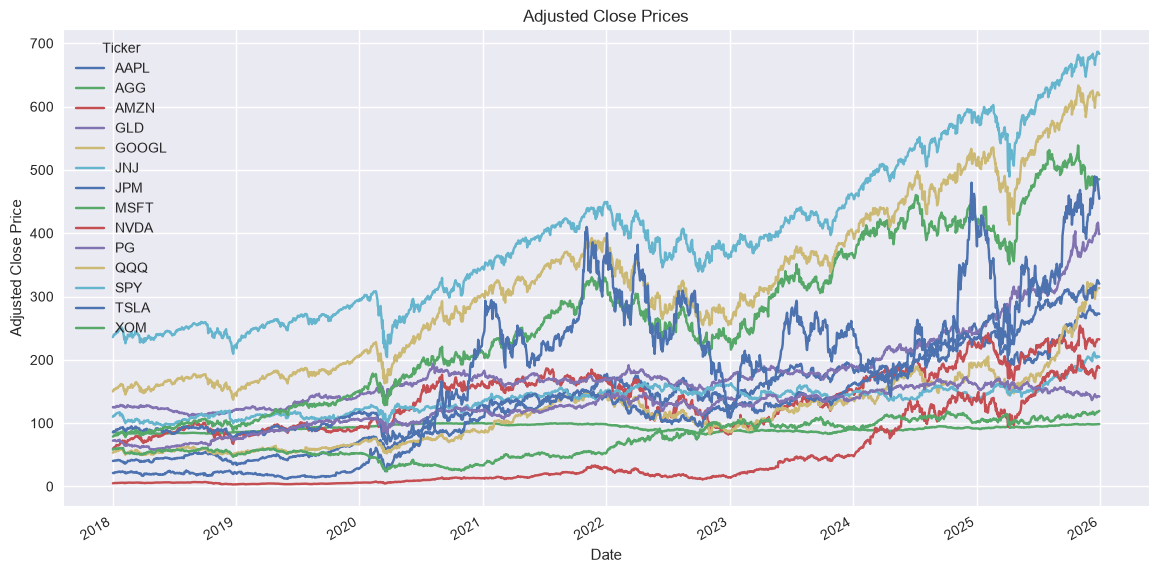

In [48]:
adjust_close.plot(figsize=(14, 7), title="Adjusted Close Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()

This chart shows the raw adjusted close price for each asset. Since assets have different price levels, this chart will be useful for checking whether the downloade data looks reasonable and realistic. 

This is biased, so we will need to normalize prices and returns.

# Normalize Prices

In [ ]:
# Take every price and divide by its firce price which reprents its growth
'''
APPLE
Date   | AAPL Price | Normalized
Day 1    100          100/100 = 1.00
Day 2    110          110/100 = 1.10
Day 3    95           95/100  =  0.95
'''

normalized_prices = adjust_close / adjust_close.iloc[0]


normalized_prices.head()

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Date,,,,,,,,,,,,,,
2018-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-03,0.999826,1.000091,1.012775,0.997363,1.017061,1.009553,1.001019,1.004654,1.065814,0.998786,1.009717,1.006325,0.989767,1.019640
2018-01-04,1.004470,0.999450,1.017309,1.002477,1.021011,1.009481,1.015359,1.013497,1.071432,1.005847,1.011483,1.010566,0.981562,1.021051
2018-01-05,1.015906,0.998809,1.033751,1.001438,1.034550,1.017813,1.008841,1.026062,1.080511,1.006508,1.021642,1.017301,0.987677,1.020228
2018-01-08,1.012133,0.998535,1.048662,1.001278,1.038203,1.019105,1.010331,1.027109,1.113619,1.011804,1.025617,1.019161,1.049543,1.024815


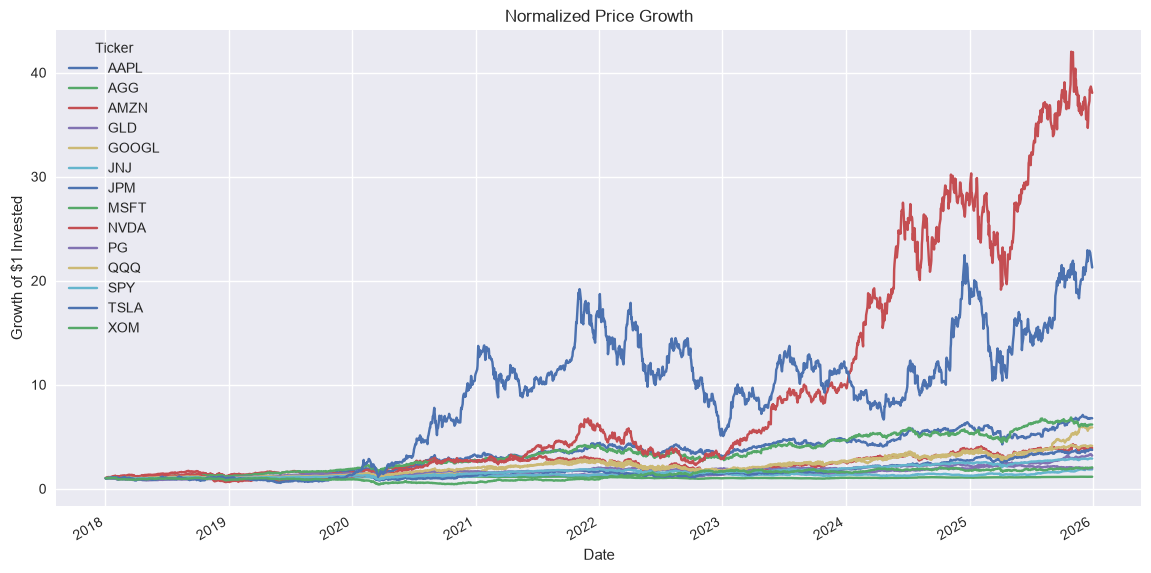

In [53]:
normalized_prices.plot(figsize=(14, 7), title="Normalized Price Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Invested")
plt.show()

This normalzied chart compares how $1 invested ine each of the chosen assets would have grown over time. This makes the assets easier to compare than raw price levels because of bias towards larger companies.

# Calculate Daily Returns

In [54]:
daily_returns = adjust_close.pct_change()

In [55]:
daily_returns.head()

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Date,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.000091,0.012775,-0.002637,0.017061,0.009553,0.001019,0.004654,0.065814,-0.001214,0.009717,0.006325,-0.010233,0.019640
2018-01-04,0.004645,-0.000641,0.004476,0.005127,0.003884,-0.000071,0.014326,0.008802,0.005271,0.007069,0.001749,0.004215,-0.008290,0.001384
2018-01-05,0.011386,-0.000642,0.016163,-0.001036,0.013260,0.008254,-0.006420,0.012397,0.008474,0.000658,0.010043,0.006664,0.006230,-0.000806
2018-01-08,-0.003714,-0.000275,0.014425,-0.000160,0.003530,0.001270,0.001477,0.001021,0.030641,0.005261,0.003891,0.001828,0.062638,0.004496


In [56]:
daily_returns.describe()

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
count,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000,2009.000000
mean,0.001140,0.000077,0.000914,0.000623,0.001074,0.000385,0.000822,0.001065,0.002334,0.000415,0.000820,0.000605,0.002323,0.000538
std,0.019401,0.003669,0.021680,0.009535,0.019523,0.012333,0.018298,0.017861,0.032318,0.012591,0.015153,0.012260,0.040118,0.018996
min,-0.128647,-0.040011,-0.140494,-0.064269,-0.116342,-0.100378,-0.149649,-0.147390,-0.187559,-0.087373,-0.119788,-0.109423,-0.210628,-0.122248
25%,-0.007925,-0.001631,-0.010250,-0.004385,-0.008510,-0.005351,-0.007638,-0.007372,-0.015115,-0.005599,-0.005957,-0.004280,-0.019163,-0.009448
50%,0.001187,0.000178,0.001084,0.000646,0.001419,0.000530,0.000872,0.001254,0.002814,0.000730,0.001365,0.000899,0.001535,0.000481
75%,0.011071,0.001849,0.012258,0.005667,0.011264,0.006217,0.009361,0.010266,0.019810,0.006882,0.008557,0.006519,0.021914,0.010647
max,0.153289,0.023721,0.135359,0.048530,0.102244,0.079977,0.180125,0.142169,0.243697,0.120091,0.120031,0.105019,0.226900,0.126868


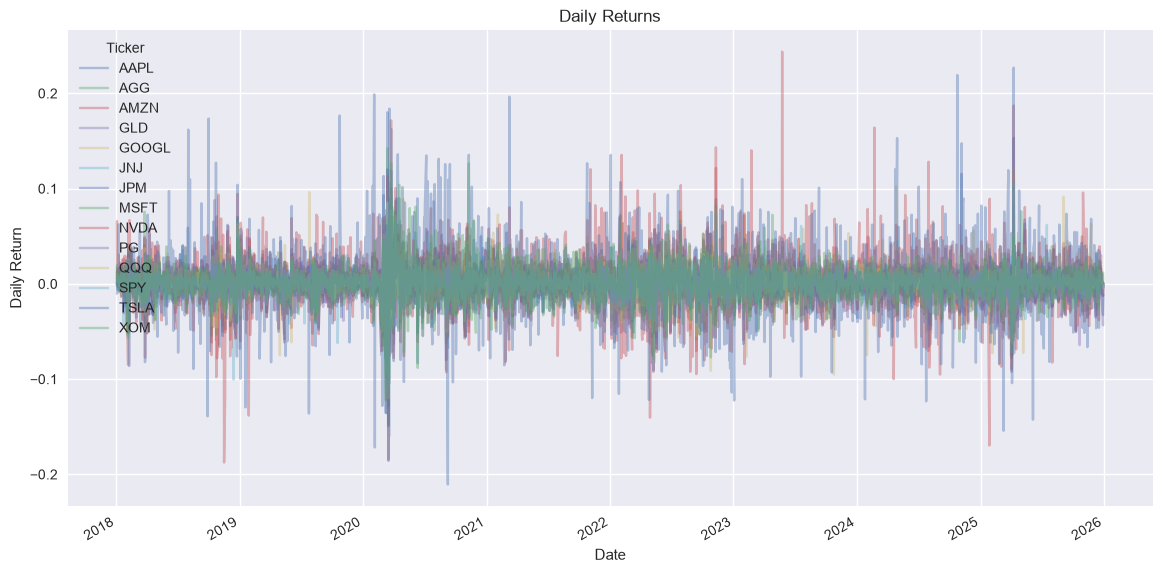

In [67]:
daily_returns.plot(figsize=(14, 7), alpha=0.4, title="Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

Daily returns are noisy as a data point, but it helps show how each one is moving from each trading day. We can ues these later to calculate volatility, covariance, correlation, and portfolio performance

In [68]:
return_correlation = daily_returns.corr()

return_correlation

Ticker,AAPL,AGG,AMZN,GLD,GOOGL,JNJ,JPM,MSFT,NVDA,PG,QQQ,SPY,TSLA,XOM
Ticker,,,,,,,,,,,,,,
AAPL,1.000000,0.110499,0.595107,0.065187,0.622435,0.319373,0.430872,0.700310,0.572102,0.361663,0.817421,0.774846,0.458186,0.309199
AGG,0.110499,1.000000,0.113778,0.326899,0.098947,0.046418,-0.034033,0.107343,0.085460,0.118648,0.132856,0.135167,0.104179,-0.030089
AMZN,0.595107,0.113778,1.000000,0.058790,0.641360,0.159332,0.324663,0.682078,0.583920,0.189718,0.782095,0.673843,0.424798,0.179402
GLD,0.065187,0.326899,0.058790,1.000000,0.083275,0.056284,-0.034106,0.061976,0.060856,0.073715,0.103189,0.095513,0.053877,0.061373
GOOGL,0.622435,0.098947,0.641360,0.083275,1.000000,0.256492,0.419447,0.708791,0.575801,0.258507,0.786683,0.730600,0.400331,0.275611
JNJ,0.319373,0.046418,0.159332,0.056284,0.256492,1.000000,0.363129,0.320616,0.115558,0.540645,0.327619,0.458099,0.076979,0.293785
JPM,0.430872,-0.034033,0.324663,-0.034106,0.419447,0.363129,1.000000,0.443962,0.359904,0.317210,0.538879,0.713632,0.293619,0.546903
MSFT,0.700310,0.107343,0.682078,0.061976,0.708791,0.320616,0.443962,1.000000,0.661554,0.369470,0.867279,0.809754,0.430536,0.265847
NVDA,0.572102,0.085460,0.583920,0.060856,0.575801,0.115558,0.359904,0.661554,1.000000,0.163402,0.791644,0.695164,0.444148,0.210456


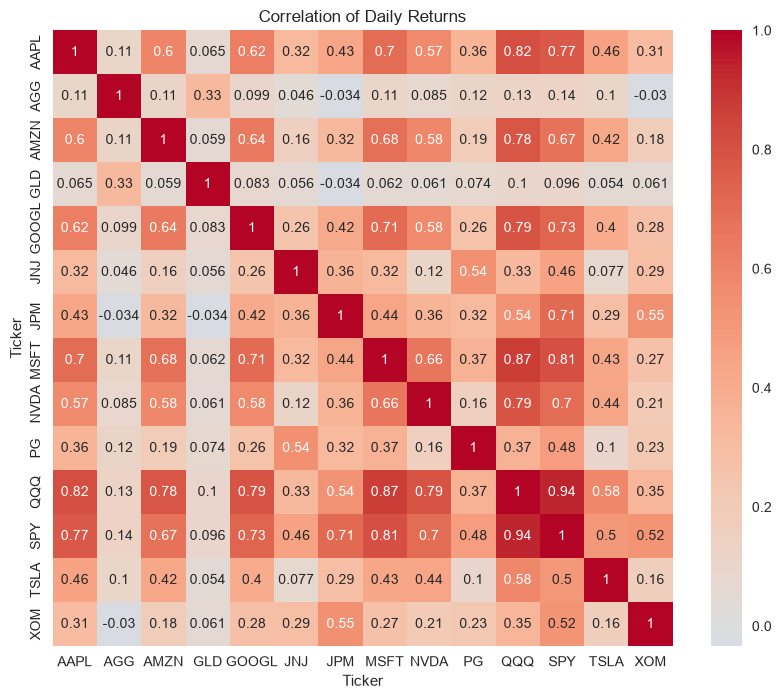

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(return_correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Daily Returns")
plt.show()

We can use this correlation heat map to help us understand which assets/tickers tend to move together. This will be important for portfolio diverisifcation depending on combining assets that are not perfectly correlated.

# Get Basic Annualized Metrics

In [71]:
TRADING_DAYS = 252

annualized_return = daily_returns.mean() * TRADING_DAYS
annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS)

print(annualized_return)
print(annualized_volatility)

Ticker
AAPL     0.287326
AGG      0.019346
AMZN     0.230284
GLD      0.156912
GOOGL    0.270602
JNJ      0.096933
JPM      0.207217
MSFT     0.268446
NVDA     0.588212
PG       0.104637
QQQ      0.206583
SPY      0.152411
TSLA     0.585406
XOM      0.135652
dtype: float64
Ticker
AAPL     0.307982
AGG      0.058242
AMZN     0.344154
GLD      0.151369
GOOGL    0.309912
JNJ      0.195777
JPM      0.290465
MSFT     0.283531
NVDA     0.513032
PG       0.199871
QQQ      0.240550
SPY      0.194623
TSLA     0.636846
XOM      0.301556
dtype: float64


In [72]:
summary_stats = pd.DataFrame({
    "annualized_return" : annualized_return,
    "annualized_volatility" : annualized_volatility
})

summary_stats

,annualized_return,annualized_volatility
Ticker,,
AAPL,0.287326,0.307982
AGG,0.019346,0.058242
AMZN,0.230284,0.344154
GLD,0.156912,0.151369
GOOGL,0.270602,0.309912
JNJ,0.096933,0.195777
JPM,0.207217,0.290465
MSFT,0.268446,0.283531
NVDA,0.588212,0.513032


# Risk Return Scatterplot

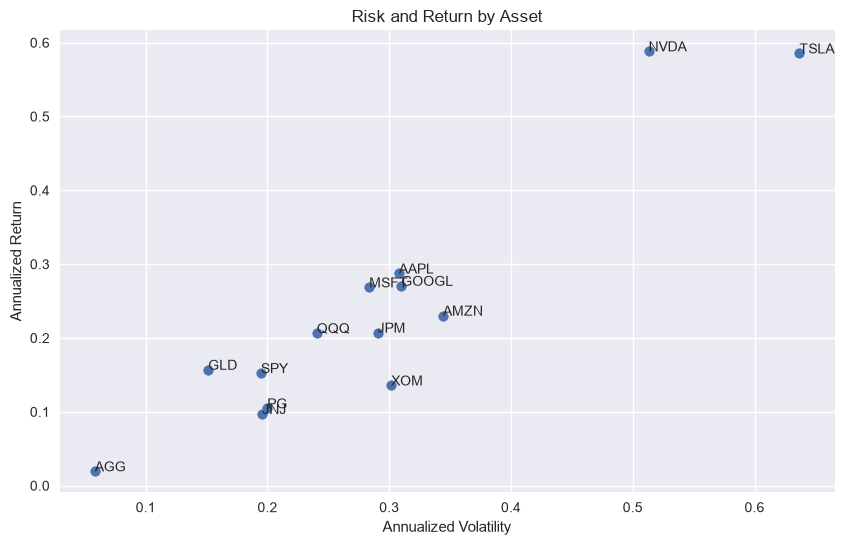

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(
    summary_stats["annualized_volatility"],
    summary_stats["annualized_return"]
)

for ticker in summary_stats.index:
    plt.text(
        summary_stats.loc[ticker, "annualized_volatility"],
        summary_stats.loc[ticker, "annualized_return"],
        ticker
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Risk and Return by Asset")
plt.show()

This chart gives an initial view of the risk-return tradeoff for each asset. Assets farther to the right have higher volatility, while the assets higher on the chart have higher historical annualized return.

# Save Outputs

In [74]:
adjust_close.to_csv(RAW_DATA_PATH / "adjusted_close_prices.csv")
daily_returns.to_csv(RAW_DATA_PATH / "daily_returns_initial.csv")
summary_stats.to_csv(RAW_DATA_PATH / "initial_summary_stats.csv")

In [75]:
print("Worked")

Worked


# Conclusion

## Initial Exploration Summary

In this notebook, we downloaded historical market data for selected assets. Leaning more top companies which tend to be technology, but we are able to adjust in future. Then we perofrmed an initial data quality check.

## Main Takeaways

- Data was able to adjust
- Adjusted close prices are available easily and can be used for return calculations.
- The data is able to cover for data from 2018 to 2025.
- Daily returns show differences in volatility across different assets.
- The corrleation heatmaps show there are assets that move together, while others don't move together which will be good for diversification.
- Our next step is for preprocessing, where we clean teh data, handle missing vals, align dates more explicit, and create a final processed dataset.